In [7]:
import control as ctrl
import matplotlib.pyplot as plt
import math
import numpy as np

# Ej a

In [8]:
G_ref = ctrl.tf([0.25], [0.003, 0.0515, 0.2, 0.25])

# Buscamso ts y sobrepico de nuestro G(S)
info = ctrl.step_info(G_ref, SettlingTimeThreshold=0.02)

ts = info['SettlingTime']
mp = info['Overshoot']

print(f"VALORES DEL SISTEMA SIN COMPENSAR:")
print(f"Tiempo de establecimiento (ts al 2%): {ts:.2f} s")
print(f"Sobrepico (Mp): {mp:.2f} %")

VALORES DEL SISTEMA SIN COMPENSAR:
Tiempo de establecimiento (ts al 2%): 2.05 s
Sobrepico (Mp): 0.00 %


## Ej c

In [13]:
G = ctrl.TransferFunction([0.25], [0.003,0.0515,0.2,0.0])
G_pid = ctrl.TransferFunction([0.42, 1.2978, 1.0025],[1,0])
L = G * G_pid
gm, pm, wg, wp = ctrl.margin(L)
gm_db = 20 * math.log10(gm)

print(f"Margen de Ganancia: {gm_db:.2f} dB")
print(f"Margen de Fase: {pm:.2f} grados")

Margen de Ganancia: inf dB
Margen de Fase: 67.80 grados


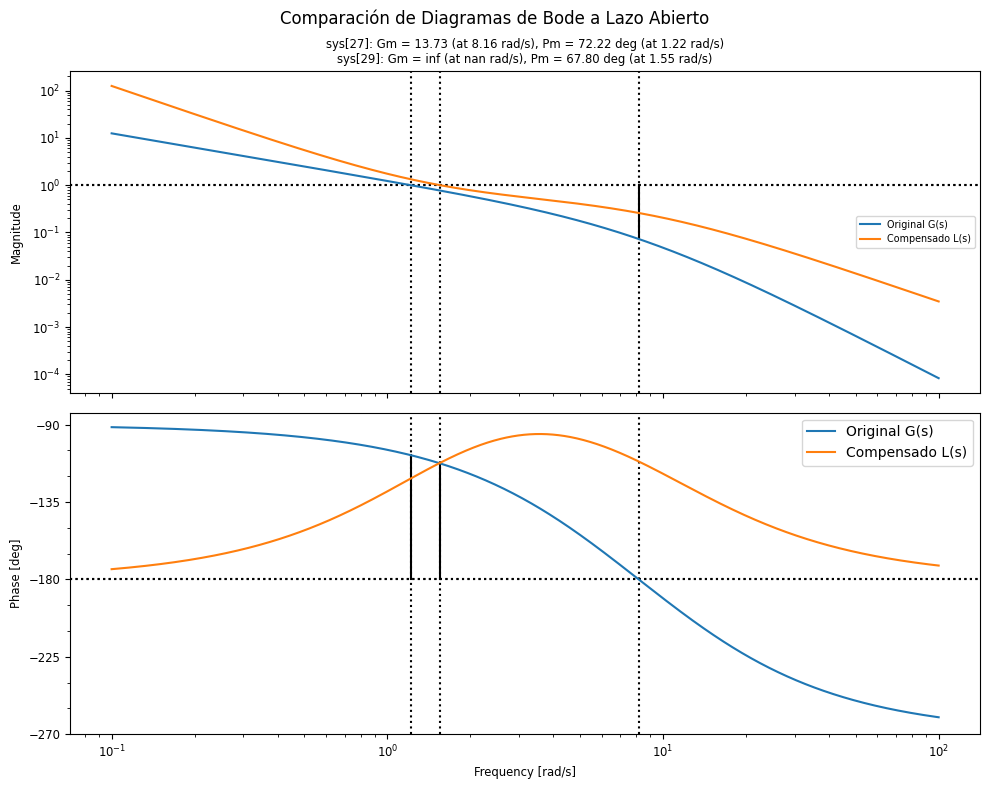

In [ ]:
plt.figure(figsize=(10, 8))
# Trazamos ambos para compararlos
ctrl.bode_plot([G, L], display_margins=True, label=['Original G(s)', 'Compensado L(s)'])
plt.legend()
plt.suptitle('Comparación de Diagramas de Bode a Lazo Abierto')
plt.show()

## Ej d

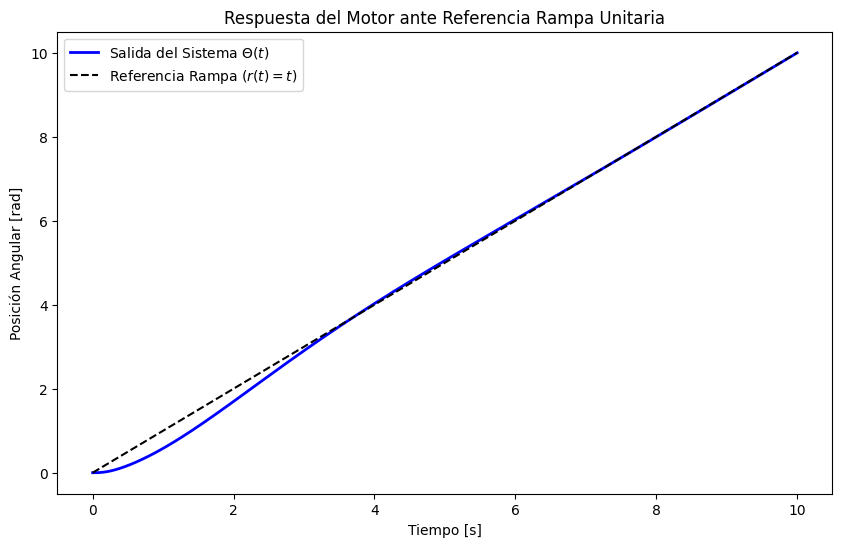

In [ ]:
G = ctrl.tf([0.25], [0.003, 0.0515, 0.2, 0])
C_pid = ctrl.tf([0.42, 1.2978, 1.0025],[1,0])

T_ref = ctrl.feedback(C_pid * G, 1)

t = np.linspace(0, 10, 1000)
t,y_ref = ctrl.forced_response(T_ref, T=t,U=t)

plt.figure(figsize=(10, 6))

plt.plot(t, y_ref, label='Salida del Sistema $\Theta(t)$', color='blue', linewidth=2)
plt.plot(t, t, label='Referencia Rampa ($r(t)=t$)', color='black', linestyle='--')

plt.title("Respuesta del Motor ante Referencia Rampa Unitaria")
plt.xlabel("Tiempo [s]")
plt.ylabel("Posición Angular [rad]")
plt.legend(loc='upper left')
plt.show()